# Plantalyze model
Modelo de machine learning para detección de especies de plantas a partir de imágenes.

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
import kagglehub
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Importar dataset

In [29]:
path = kagglehub.dataset_download("marquis03/plants-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plants-classification' dataset.
Path to dataset files: /kaggle/input/plants-classification


Nota: Este dataset ya estaba separado con una distribución de **70/20/10**, 70% train, 20% test y 10% validation.

In [30]:
train_dir = path + "/train"
test_dir = path + "/test"
val_dir = path + "/val"

### Redimensionar todas las imágenes a 128 x 128
Sin data augmentation para el modelo.

Found 21000 images belonging to 30 classes.
Found 6000 images belonging to 30 classes.
Found 3000 images belonging to 30 classes.
(8, 128, 128, 3)


<Figure size 640x480 with 0 Axes>

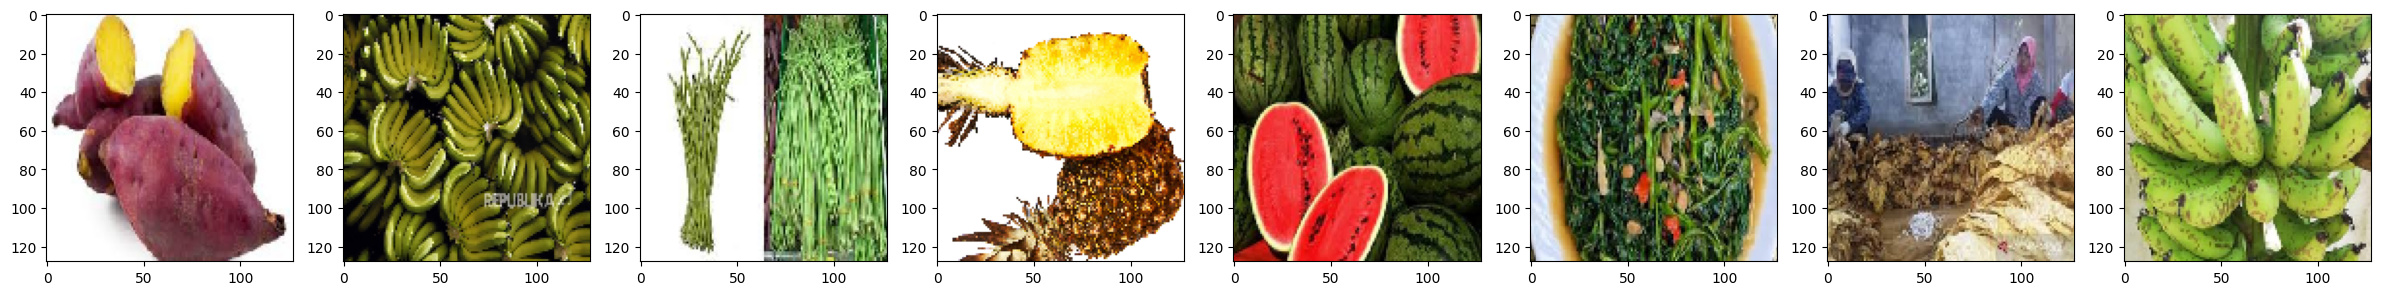

In [31]:
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=8,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=8,
    class_mode='categorical'
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=8,
    class_mode='categorical'
)

images , labels = train_generator[0]

print(images.shape)

plt.figure()
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

# Data augmentation
Data augmentation de train en caso de ser necesario, se guarda en una carpeta aparte que en caso de utilizarse se debe unificar con el train principal.

Found 21000 images belonging to 30 classes.
(8, 128, 128, 3)


<Figure size 640x480 with 0 Axes>

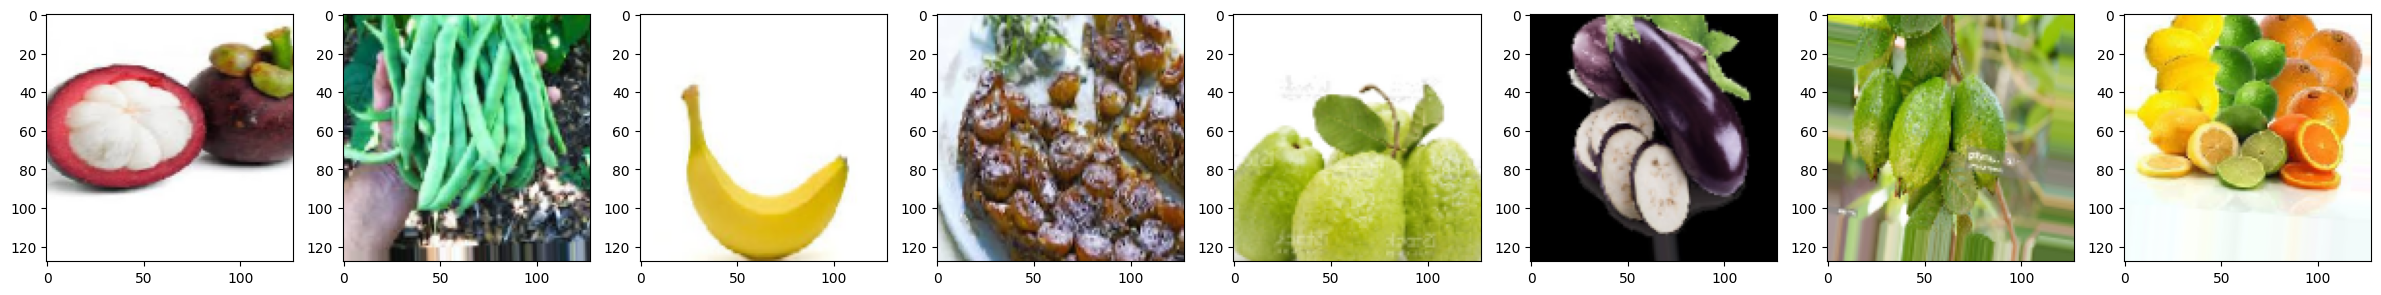

In [32]:
aug_dir = '/kaggle/working/train_augmented'
os.makedirs(aug_dir, exist_ok=True)

train_datagen = ImageDataGenerator(
							rescale = 1./255,
							rotation_range = 10,
							width_shift_range = 0.2,
							zoom_range = 0.3,
							horizontal_flip = True)

train_aug_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (128, 128),
							batch_size = 8,
							class_mode ='categorical',
              save_to_dir= aug_dir,
              save_prefix='aug',
              save_format='jpg'
							)

images , labels = train_aug_generator[0]

print(images.shape)

plt.figure()
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])